# CheXpert Plus — Exploratory Data Analysis (Findings Labels)

This notebook performs EDA on the **findings.csv** file of the [CheXpert Plus](https://stanfordaimi.azurewebsites.net/datasets/5158c524-d3ab-4e02-96e9-6ee9efc110a1) dataset (Stanford AIMI), hosted on **Redivis**.

CheXpert Plus extends the original CheXpert dataset with paired radiology reports (findings/impressions) for ~223,000 chest X-ray studies from ~64,000 patients at Stanford Health Care. This notebook only analyzes the **structured label file** (`findings.csv`), which mirrors the original 14 CheXpert observation labels automatically extracted from reports via the CheXpert labeler (NLP-based rule labeler, Irvin et al. 2019).

**Label encoding (standard CheXpert convention):**
| Value | Meaning |
|---|---|
| `1.0` | Positive mention |
| `0.0` | Negative mention |
| `-1.0` | Uncertain mention |
| `NaN` / blank | Not mentioned |

**Columns expected:**
`path_to_image`, `Enlarged Cardiomediastinum`, `Cardiomegaly`, `Lung Opacity`, `Lung Lesion`, `Edema`, `Consolidation`, `Pneumonia`, `Atelectasis`, `Pneumothorax`, `Pleural Effusion`, `Pleural Other`, `Fracture`, `Support Devices`, `No Finding`

> Note: This notebook analyzes labels only. The paired `reports.csv` / impressions text is out of scope here (see the capstone's separate NLP/report notebooks).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)


## 1. Load Data

Update `DATA_PATH` to point to your local copy of `findings.csv` (exported from the CheXpert Plus Redivis dataset / your `finding_fixed.json` conversion).

In [6]:
DATA_PATH = "findings.csv"  # <-- update this path if needed

df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()


Rows: 223,462 | Columns: 15


,path_to_image,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
0,train/patient42142/study5/view1_frontal.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,train/patient42142/study8/view1_frontal.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,train/patient42142/study2/view1_frontal.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,train/patient42142/study4/view1_frontal.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,train/patient42142/study3/view1_frontal.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [7]:
LABEL_COLS = [
    "Enlarged Cardiomediastinum",
    "Cardiomegaly",
    "Lung Opacity",
    "Lung Lesion",
    "Edema",
    "Consolidation",
    "Pneumonia",
    "Atelectasis",
    "Pneumothorax",
    "Pleural Effusion",
    "Pleural Other",
    "Fracture",
    "Support Devices",
    "No Finding",
]

missing_expected = [c for c in LABEL_COLS if c not in df.columns]
if missing_expected:
    print("WARNING - expected columns not found:", missing_expected)
else:
    print("All 14 expected CheXpert label columns present.")


All 14 expected CheXpert label columns present.


## 2. Basic Structure & Data Types

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 223462 entries, 0 to 223461
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   path_to_image               223462 non-null  str    
 1   Enlarged Cardiomediastinum  23967 non-null   float64
 2   Cardiomegaly                23786 non-null   float64
 3   Lung Opacity                33951 non-null   float64
 4   Lung Lesion                 4278 non-null    float64
 5   Edema                       19278 non-null   float64
 6   Consolidation               17180 non-null   float64
 7   Pneumonia                   4998 non-null    float64
 8   Atelectasis                 17674 non-null   float64
 9   Pneumothorax                25670 non-null   float64
 10  Pleural Effusion            37378 non-null   float64
 11  Pleural Other               2435 non-null    float64
 12  Fracture                    6164 non-null    float64
 13  Support Devices          

In [9]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
path_to_image,223462,223462,train/patient42142/study5/view1_frontal.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Enlarged Cardiomediastinum,23967.0,NaN,NaN,NaN,-0.115951,0.668704,-1.0,-1.0,0.0,0.0,1.0
Cardiomegaly,23786.0,NaN,NaN,NaN,0.395905,0.608149,-1.0,0.0,0.0,1.0,1.0
Lung Opacity,33951.0,NaN,NaN,NaN,0.949987,0.23173,-1.0,1.0,1.0,1.0,1.0
Lung Lesion,4278.0,NaN,NaN,NaN,0.708509,0.649006,-1.0,1.0,1.0,1.0,1.0
Edema,19278.0,NaN,NaN,NaN,0.490767,0.727121,-1.0,0.0,1.0,1.0,1.0
Consolidation,17180.0,NaN,NaN,NaN,-0.103551,0.759624,-1.0,-1.0,0.0,0.0,1.0
Pneumonia,4998.0,NaN,NaN,NaN,-0.557623,0.78291,-1.0,-1.0,-1.0,0.0,1.0
Atelectasis,17674.0,NaN,NaN,NaN,0.043284,0.994351,-1.0,-1.0,1.0,1.0,1.0
Pneumothorax,25670.0,NaN,NaN,NaN,0.221621,0.476663,-1.0,0.0,0.0,0.0,1.0


### Duplicate rows / images

In [10]:
n_dupe_rows = df.duplicated().sum()
n_dupe_paths = df["path_to_image"].duplicated().sum()
print(f"Fully duplicated rows: {n_dupe_rows}")
print(f"Duplicated image paths: {n_dupe_paths}")


Fully duplicated rows: 0
Duplicated image paths: 0


## 3. Parsing `path_to_image`

CheXpert paths follow the pattern:
`<split>/patient<ID>/study<N>/view<K>_<frontal|lateral>.jpg`

We extract `split`, `patient_id`, `study_id`, `view_id`, and `view_position` for patient/study-level analysis.


In [11]:
pattern = re.compile(
    r"(?P<split>[^/]+)/patient(?P<patient_id>\d+)/study(?P<study_id>\d+)/"
    r"view(?P<view_id>\d+)_(?P<view_position>\w+)"
)

extracted = df["path_to_image"].astype(str).str.extract(pattern)
df = pd.concat([df, extracted], axis=1)

n_unparsed = df["patient_id"].isna().sum()
print(f"Rows that failed to parse: {n_unparsed} / {len(df)}")
df[["path_to_image", "split", "patient_id", "study_id", "view_id", "view_position"]].head()


Rows that failed to parse: 0 / 223462


,path_to_image,split,patient_id,study_id,view_id,view_position
0,train/patient42142/study5/view1_frontal.jpg,train,42142,5,1,frontal
1,train/patient42142/study8/view1_frontal.jpg,train,42142,8,1,frontal
2,train/patient42142/study2/view1_frontal.jpg,train,42142,2,1,frontal
3,train/patient42142/study4/view1_frontal.jpg,train,42142,4,1,frontal
4,train/patient42142/study3/view1_frontal.jpg,train,42142,3,1,frontal


In [12]:
n_patients = df["patient_id"].nunique()
n_studies = df.dropna(subset=["patient_id", "study_id"]).groupby(["patient_id", "study_id"]).ngroups
n_views = len(df)

print(f"Unique patients : {n_patients:,}")
print(f"Unique studies  : {n_studies:,}")
print(f"Total views/rows: {n_views:,}")
print(f"Avg views/study : {n_views / n_studies:.2f}")


Unique patients : 64,725
Unique studies  : 187,711
Total views/rows: 223,462
Avg views/study : 1.19


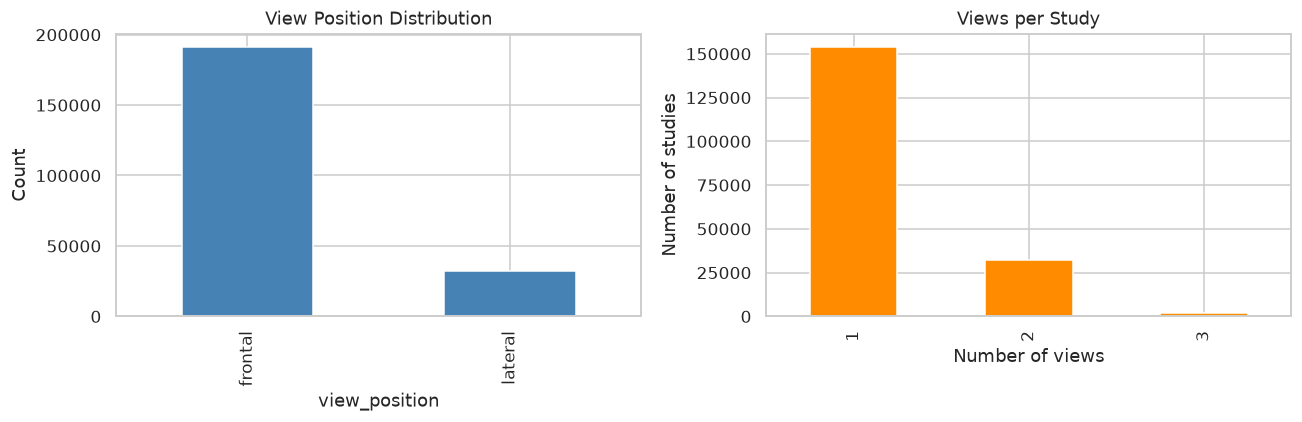

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["view_position"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("View Position Distribution")
axes[0].set_ylabel("Count")

views_per_study = df.dropna(subset=["patient_id", "study_id"]).groupby(["patient_id", "study_id"]).size()
views_per_study.value_counts().sort_index().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Views per Study")
axes[1].set_xlabel("Number of views")
axes[1].set_ylabel("Number of studies")

plt.tight_layout()
plt.show()


split
train    223228
valid       234
Name: count, dtype: int64


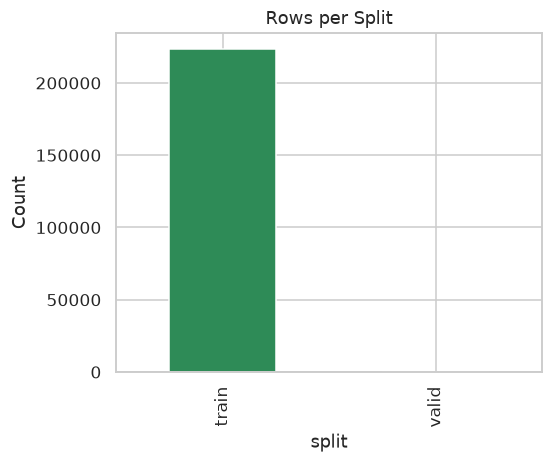

In [14]:
split_counts = df["split"].value_counts()
print(split_counts)

if len(split_counts) > 1:
    split_counts.plot(kind="bar", color="seagreen", figsize=(5, 4), title="Rows per Split")
    plt.ylabel("Count")
    plt.show()
else:
    print("Only one split present in this file (typically 'train' for findings.csv).")


## 4. Missingness Across Label Columns

In CheXpert, a blank/NaN cell means the observation was **not mentioned** in the report — this is informative, not a data-quality issue, but worth visualizing.

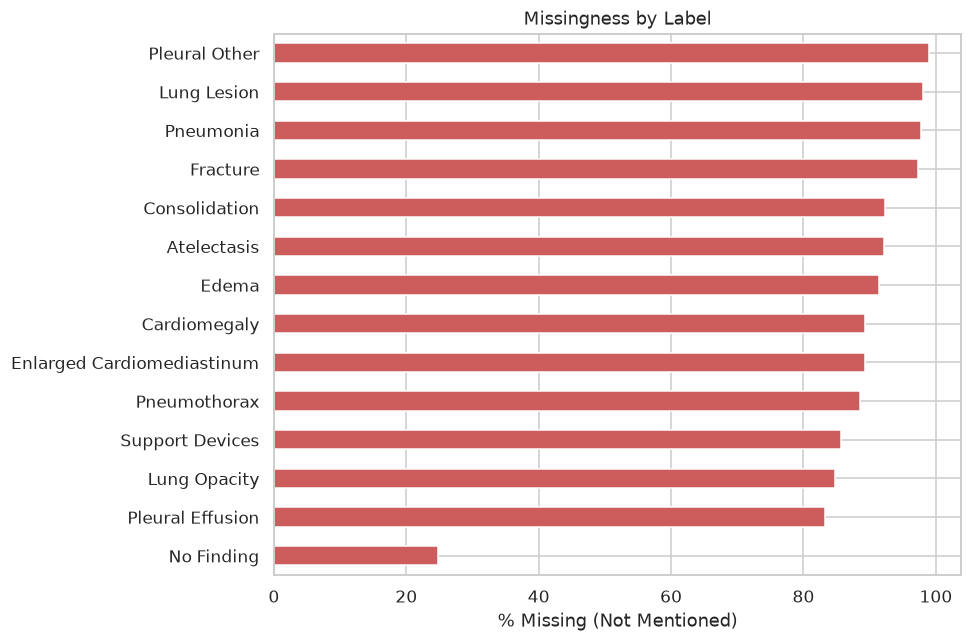

,pct_missing
Pleural Other,98.910329
Lung Lesion,98.085581
Pneumonia,97.763378
Fracture,97.241589
Consolidation,92.311892
Atelectasis,92.090825
Edema,91.373030
Cardiomegaly,89.355685
Enlarged Cardiomediastinum,89.274687
Pneumothorax,88.512588


In [15]:
missing_pct = df[LABEL_COLS].isna().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 6))
missing_pct.plot(kind="barh", color="indianred")
plt.xlabel("% Missing (Not Mentioned)")
plt.title("Missingness by Label")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

missing_pct.to_frame("pct_missing")


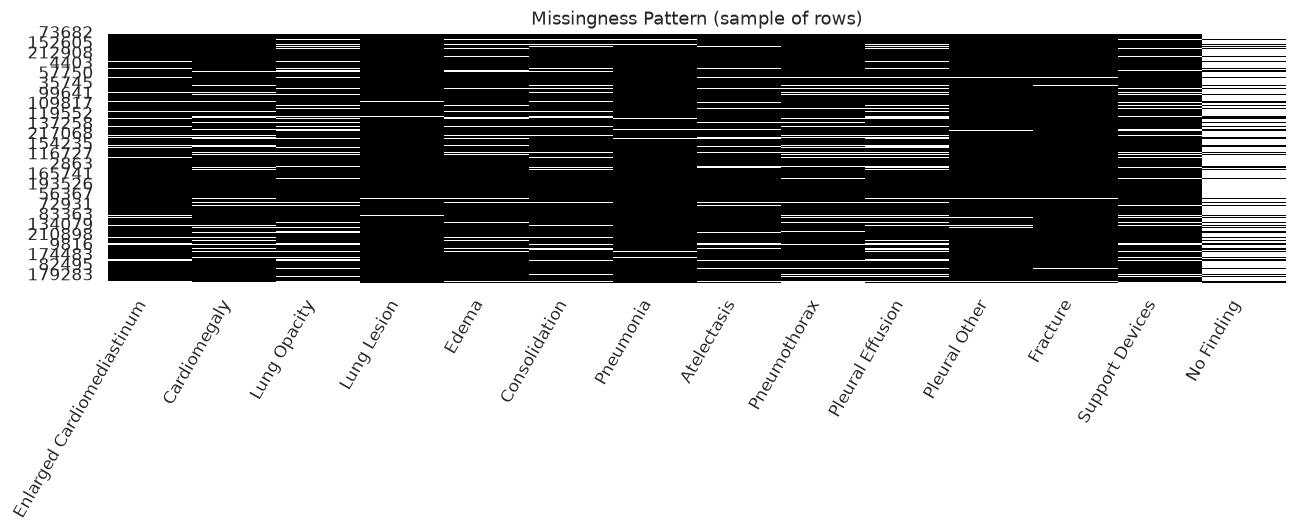

In [16]:
plt.figure(figsize=(12, 5))
sample = df[LABEL_COLS].sample(min(2000, len(df)), random_state=42)
sns.heatmap(sample.isna(), cbar=False, cmap="Greys")
plt.title("Missingness Pattern (sample of rows)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


## 5. Label Value Distribution (Positive / Negative / Uncertain / Not Mentioned)

In [17]:
def label_breakdown(df, cols):
    rows = []
    for c in cols:
        vc = df[c].value_counts(dropna=False)
        rows.append({
            "label": c,
            "positive (1.0)": vc.get(1.0, 0),
            "negative (0.0)": vc.get(0.0, 0),
            "uncertain (-1.0)": vc.get(-1.0, 0),
            "not_mentioned (NaN)": df[c].isna().sum(),
        })
    out = pd.DataFrame(rows).set_index("label")
    out["total"] = out.sum(axis=1)
    return out

breakdown = label_breakdown(df, LABEL_COLS)
breakdown


,positive (1.0),negative (0.0),uncertain (-1.0),not_mentioned (NaN),total
label,,,,,
Enlarged Cardiomediastinum,4130,12928,6909,199495,223462
Cardiomegaly,10971,11261,1554,199676,223462
Lung Opacity,32358,1488,105,189511,223462
Lung Lesion,3490,329,459,219184,223462
Edema,12148,4443,2687,204184,223462
Consolidation,4159,7083,5938,206282,223462
Pneumonia,915,381,3702,218464,223462
Atelectasis,9136,167,8371,205788,223462
Pneumothorax,6391,18577,702,197792,223462


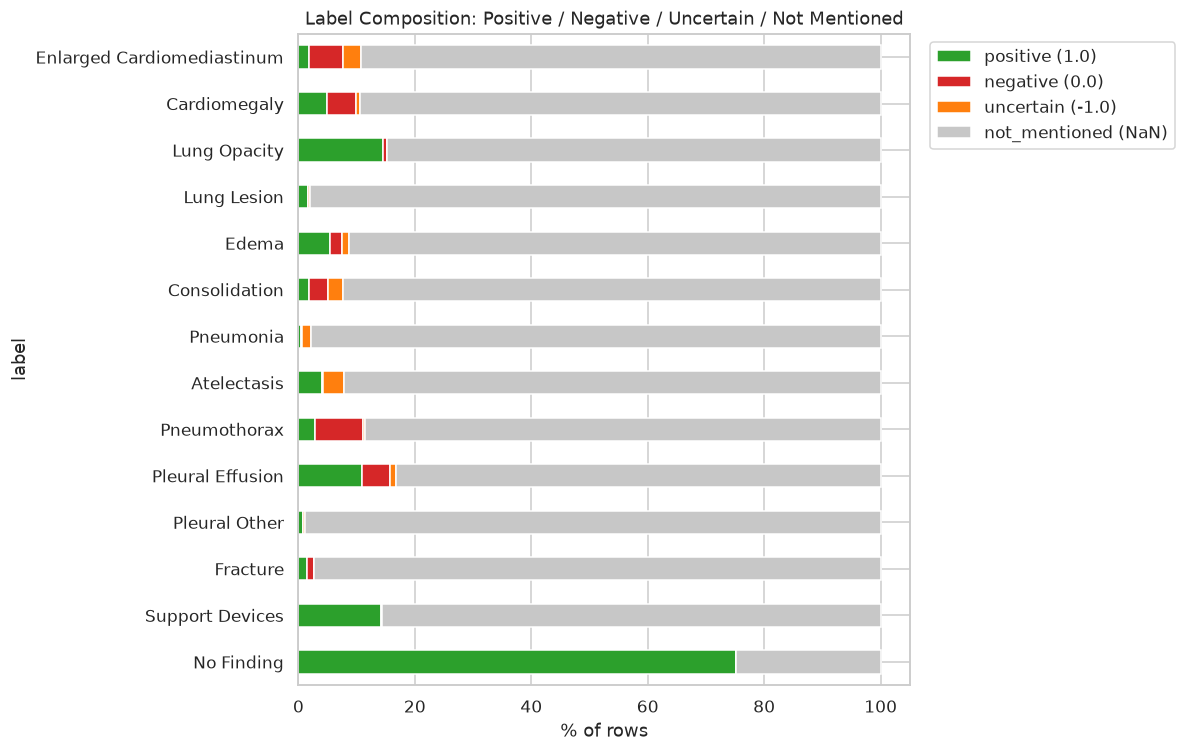

In [18]:
pct_breakdown = breakdown.drop(columns="total").div(breakdown["total"], axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 7))
pct_breakdown.plot(kind="barh", stacked=True, ax=ax,
                    color=["#2ca02c", "#d62728", "#ff7f0e", "#c7c7c7"])
ax.set_xlabel("% of rows")
ax.set_title("Label Composition: Positive / Negative / Uncertain / Not Mentioned")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Positive-label prevalence (most clinically relevant view)

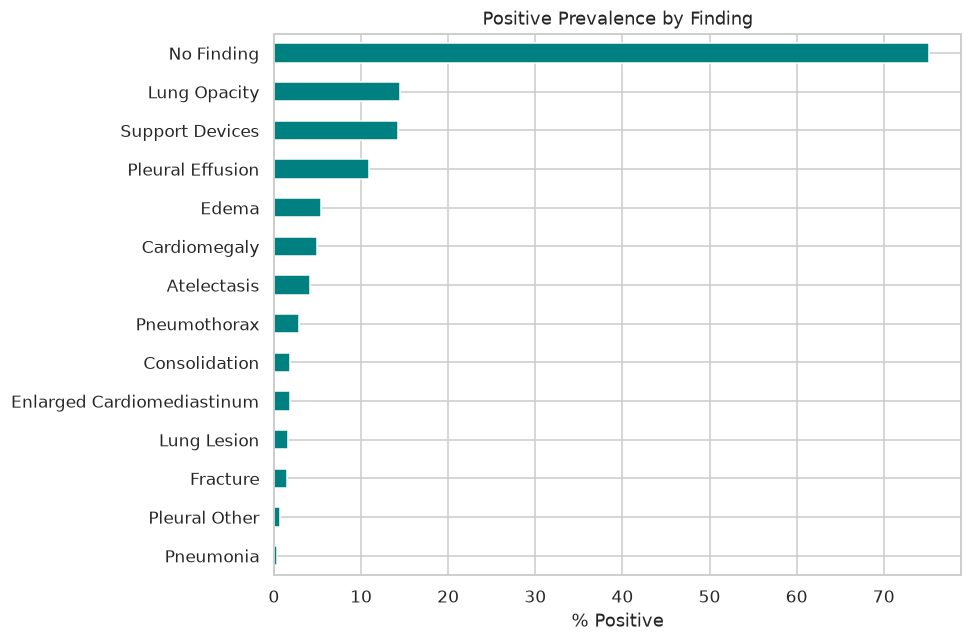

,pct_positive
No Finding,75.150585
Lung Opacity,14.480314
Support Devices,14.190332
Pleural Effusion,10.968755
Edema,5.436271
Cardiomegaly,4.909560
Atelectasis,4.088391
Pneumothorax,2.859994
Consolidation,1.861167
Enlarged Cardiomediastinum,1.848189


In [19]:
pos_rate = (df[LABEL_COLS] == 1.0).mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 6))
pos_rate.plot(kind="barh", color="teal")
plt.xlabel("% Positive")
plt.title("Positive Prevalence by Finding")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

pos_rate.to_frame("pct_positive")


### Uncertainty rate — which findings are hardest to call?

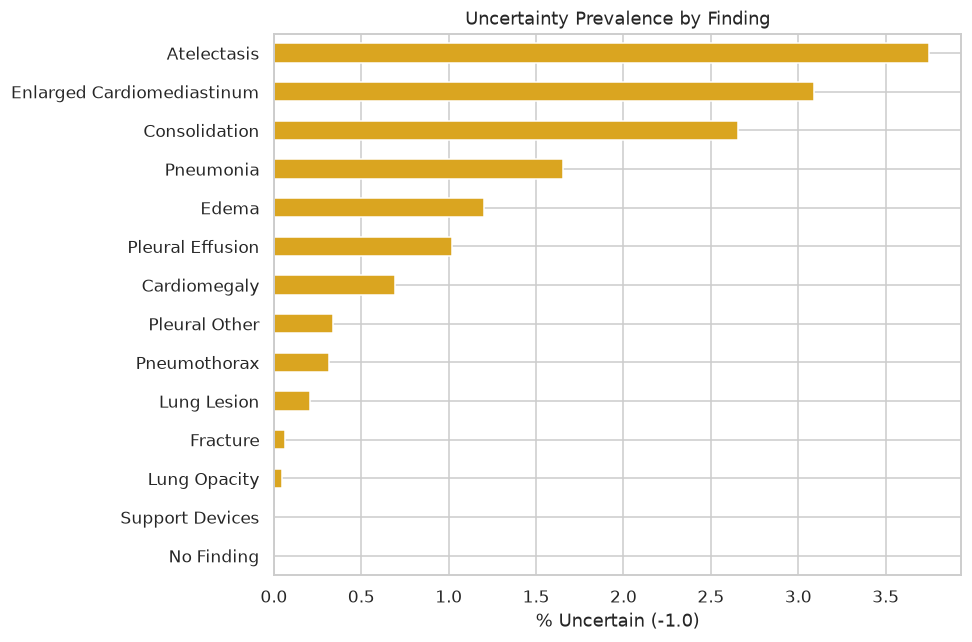

In [20]:
uncertain_rate = (df[LABEL_COLS] == -1.0).mean().sort_values(ascending=False) * 100

plt.figure(figsize=(9, 6))
uncertain_rate.plot(kind="barh", color="goldenrod")
plt.xlabel("% Uncertain (-1.0)")
plt.title("Uncertainty Prevalence by Finding")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 6. `No Finding` Sanity Checks

`No Finding` should be mutually exclusive-ish with pathology labels: if `No Finding == 1`, all other labels are expected to be 0 or NaN. We check for violations (rows where `No Finding == 1` but some pathology is also positive).


In [21]:
pathology_cols = [c for c in LABEL_COLS if c != "No Finding"]

no_finding_rows = df[df["No Finding"] == 1.0]
violations = no_finding_rows[(no_finding_rows[pathology_cols] == 1.0).any(axis=1)]

print(f"Rows with No Finding == 1 : {len(no_finding_rows):,}")
print(f"Of these, rows with a co-occurring positive pathology label (should be ~0): {len(violations):,}")

if len(violations):
    display_cols = ["path_to_image"] + pathology_cols
    violations[display_cols].head(10)


Rows with No Finding == 1 : 167,933
Of these, rows with a co-occurring positive pathology label (should be ~0): 1,068


## 7. Multi-Label Characteristics

CheXpert is a multi-label problem — a single study can have several positive findings simultaneously.

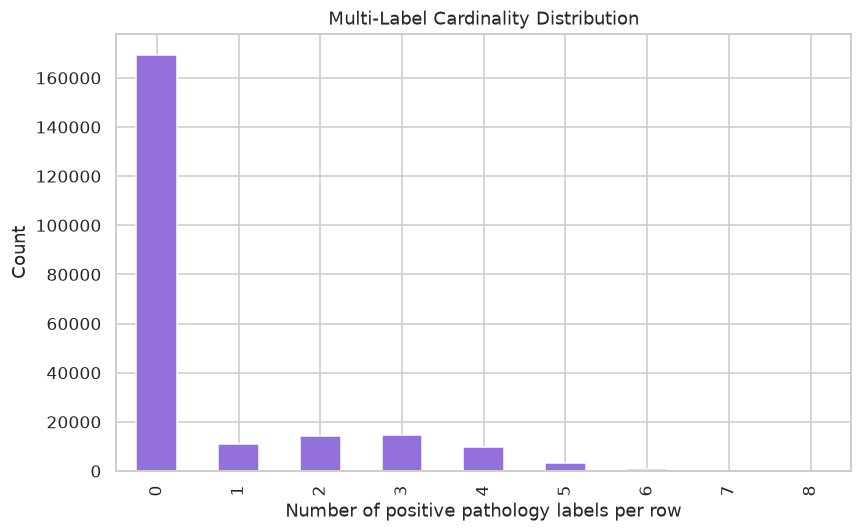

count    223462.000000
mean          0.648200
std           1.299192
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.000000
Name: n_positive_labels, dtype: float64


In [22]:
df["n_positive_labels"] = (df[pathology_cols] == 1.0).sum(axis=1)

plt.figure(figsize=(8, 5))
df["n_positive_labels"].value_counts().sort_index().plot(kind="bar", color="mediumpurple")
plt.xlabel("Number of positive pathology labels per row")
plt.ylabel("Count")
plt.title("Multi-Label Cardinality Distribution")
plt.tight_layout()
plt.show()

print(df["n_positive_labels"].describe())


### Co-occurrence of positive findings

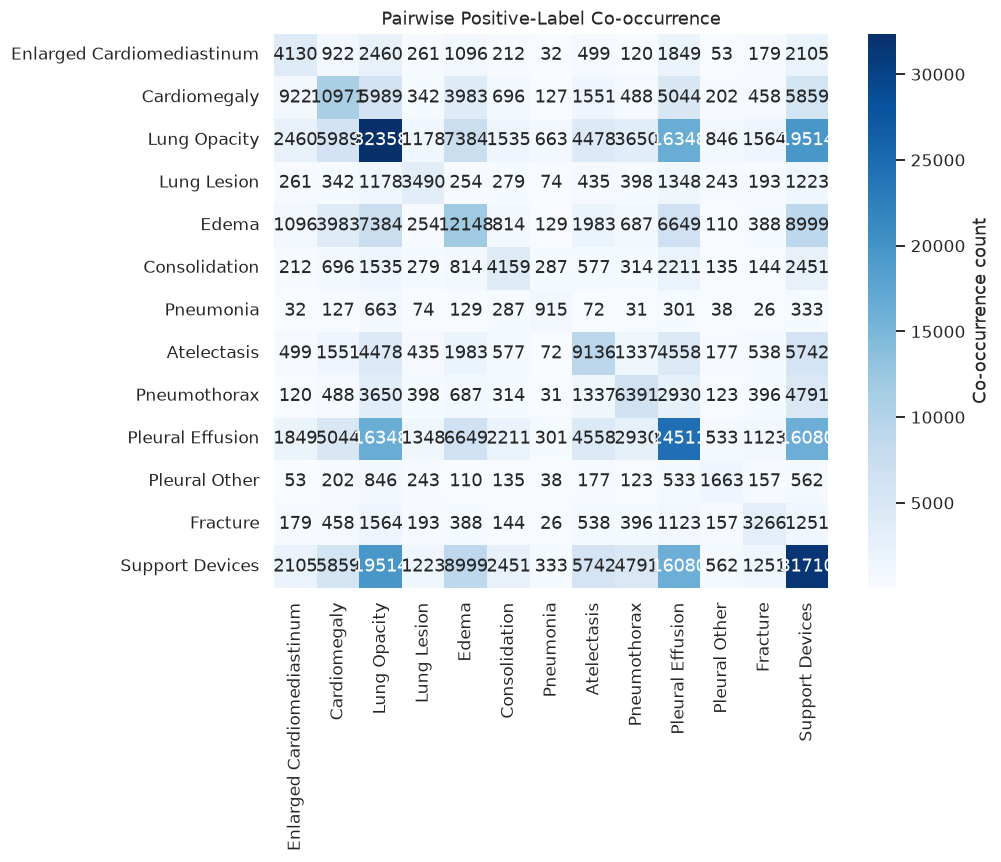

In [23]:
pos_matrix = (df[pathology_cols] == 1.0).astype(int)
cooc = pos_matrix.T.dot(pos_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(cooc, annot=True, fmt="d", cmap="Blues", square=True, cbar_kws={"label": "Co-occurrence count"})
plt.title("Pairwise Positive-Label Co-occurrence")
plt.tight_layout()
plt.show()


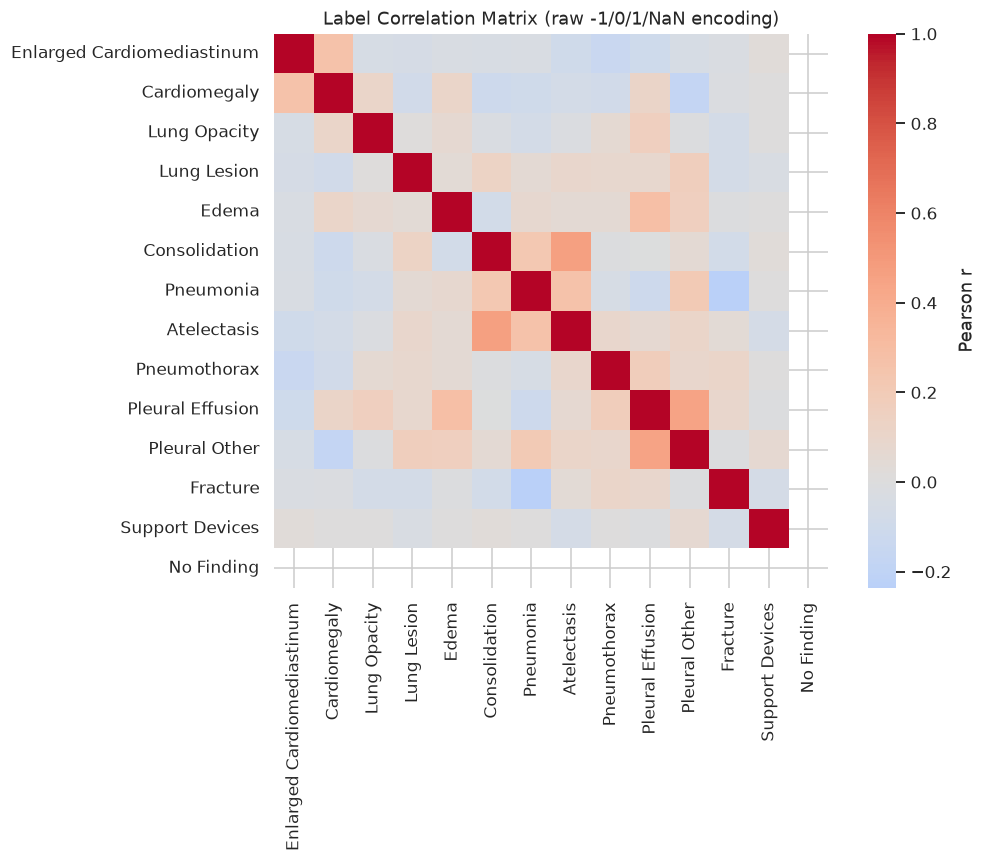

In [24]:
corr = df[LABEL_COLS].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, square=True, cbar_kws={"label": "Pearson r"})
plt.title("Label Correlation Matrix (raw -1/0/1/NaN encoding)")
plt.tight_layout()
plt.show()


## 8. Patient-Level Summary

Since multiple views/studies can belong to the same patient, this checks for patient-level label consistency and identifies the most "complex" patients (most positive findings across all their studies).

In [25]:
patient_pos = df.groupby("patient_id")[pathology_cols].max()  # max(1.0) = ever-positive across studies
patient_pos["n_distinct_positive_findings"] = (patient_pos == 1.0).sum(axis=1)

top_complex_patients = patient_pos.sort_values("n_distinct_positive_findings", ascending=False).head(10)
top_complex_patients[["n_distinct_positive_findings"]]


,n_distinct_positive_findings
patient_id,
24901,11
26257,11
03230,10
07379,10
41351,10
43384,10
27900,10
10924,10
02001,10


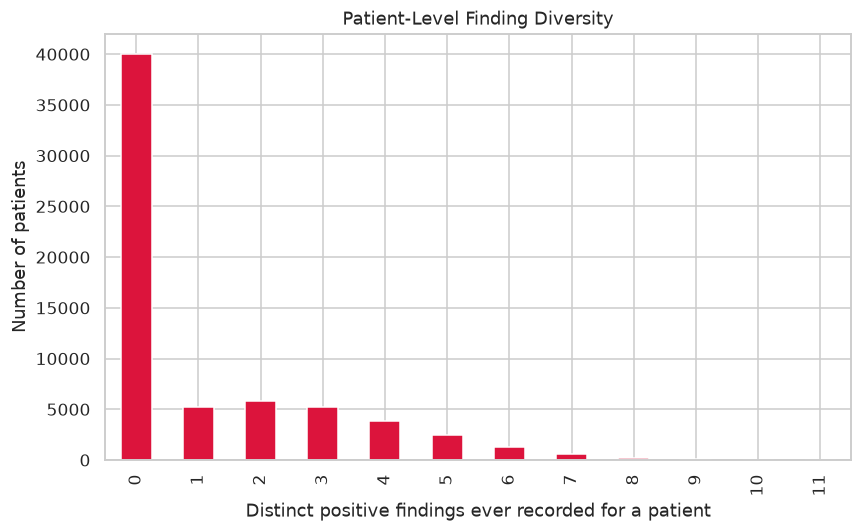

In [26]:
plt.figure(figsize=(8, 5))
patient_pos["n_distinct_positive_findings"].value_counts().sort_index().plot(kind="bar", color="crimson")
plt.xlabel("Distinct positive findings ever recorded for a patient")
plt.ylabel("Number of patients")
plt.title("Patient-Level Finding Diversity")
plt.tight_layout()
plt.show()


## 9. Class Imbalance Summary (for modeling)

Useful reference table if these labels feed into a classifier or the RAG retrieval/report-generation pipeline (e.g. for loss weighting or stratified sampling).

In [27]:
imbalance = pd.DataFrame({
    "positive_rate_%": pos_rate,
    "negative_rate_%": (df[LABEL_COLS] == 0.0).mean() * 100,
    "uncertain_rate_%": uncertain_rate,
    "missing_rate_%": missing_pct,
})
imbalance["pos_neg_ratio"] = imbalance["positive_rate_%"] / imbalance["negative_rate_%"].replace(0, np.nan)
imbalance.sort_values("positive_rate_%", ascending=False).round(2)


,positive_rate_%,negative_rate_%,uncertain_rate_%,missing_rate_%,pos_neg_ratio
No Finding,75.15,0.00,0.00,24.85,NaN
Lung Opacity,14.48,0.67,0.05,84.81,21.75
Support Devices,14.19,0.17,0.00,85.64,84.11
Pleural Effusion,10.97,4.74,1.02,83.27,2.32
Edema,5.44,1.99,1.20,91.37,2.73
Cardiomegaly,4.91,5.04,0.70,89.36,0.97
Atelectasis,4.09,0.07,3.75,92.09,54.71
Pneumothorax,2.86,8.31,0.31,88.51,0.34
Consolidation,1.86,3.17,2.66,92.31,0.59
Enlarged Cardiomediastinum,1.85,5.79,3.09,89.27,0.32


## 10. Export Summary Artifacts

Saves the key summary tables to CSV for reuse in the report/paper or downstream modeling notebooks.

In [28]:
out_dir = Path("eda_outputs")
out_dir.mkdir(exist_ok=True)

breakdown.to_csv(out_dir / "label_breakdown.csv")
imbalance.to_csv(out_dir / "class_imbalance_summary.csv")
cooc.to_csv(out_dir / "label_cooccurrence_matrix.csv")

print("Saved summary artifacts to:", out_dir.resolve())


Saved summary artifacts to: /home/yash/Documents/Major/eda_outputs


## 11. Key Takeaways (fill in after running)

- Dataset size: **`{n_studies}` studies**, **`{n_patients}` patients**, **`{n_views}` images** *(update with printed values above)*.
- Most prevalent positive finding: *fill in from Section 5*.
- Most uncertain finding: *fill in from Section 5*.
- `No Finding` consistency check: *fill in from Section 6*.
- Average positive labels per study: *fill in from Section 7*.
- Strongest co-occurring pairs: *fill in from Section 7 heatmap* (e.g. Edema–Consolidation, Atelectasis–Pleural Effusion are commonly correlated in CheXpert).

> Next steps for the capstone: use this label distribution to design a **stratified train/val split** and to inform **retrieval weighting / evaluation stratification** for the multimodal RAG report-generation pipeline.
